In [ ]:
!pip install shap scikit-learn tensorflow matplotlib seaborn pandas numpy streamlit pyngrok fpdf -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 64.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, f1_score)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, Layer,
                                     Softmax, GRU, Bidirectional,
                                     GlobalAveragePooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

import shap
import io

print("✅ All imports successful")
print(f"   TensorFlow : {tf.__version__}")
print(f"   NumPy      : {np.__version__}")
print(f"   Pandas     : {pd.__version__}")

✅ All imports successful
   TensorFlow : 2.19.0
   NumPy      : 2.0.2
   Pandas     : 2.2.2


In [ ]:
from google.colab import files

print("📂 Upload your student_academic_growth_dataset.csv file")
uploaded = files.upload()

df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

print(f"✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(df.head(6))

📂 Upload your student_academic_growth_dataset.csv file


Saving student_academic_growth_dataset.csv to student_academic_growth_dataset.csv
✅ Dataset loaded: 300 rows × 9 columns
  student_id student_type  timestep  marks  study_hours  attendance_pct  \
0     STU001    declining         1     48          4.1              65   
1     STU001    declining         2     45          3.8              65   
2     STU001    declining         3     41          3.4              62   
3     STU001    declining         4     40          3.3              56   
4     STU001    declining         5     24          2.9              57   
5     STU001    declining         6     24          2.7              63   

   assignment_completion  sleep_hours  focus_score  
0                   0.60          7.6          7.1  
1                   0.55          7.6          7.3  
2                   0.53          7.2          6.6  
3                   0.47          7.2          6.8  
4                   0.40          6.8          6.3  
5                   0.35          6

📊 Dataset Statistics
       timestep   marks  study_hours  attendance_pct  assignment_completion  \
count    300.00  300.00       300.00          300.00                 300.00   
mean       3.50   61.30         3.24           75.83                   0.70   
std        1.71   16.69         1.20           12.49                   0.17   
min        1.00   22.00         0.50           45.00                   0.29   
25%        2.00   50.00         2.30           66.75                   0.57   
50%        3.50   62.50         3.30           77.00                   0.71   
75%        5.00   71.00         4.10           86.00                   0.83   
max        6.00   98.00         6.00          100.00                   1.00   

       sleep_hours  focus_score  
count       300.00       300.00  
mean          6.58         6.66  
std           1.12         1.49  
min           4.30         2.50  
25%           5.60         5.80  
50%           6.40         6.80  
75%           7.50         7.

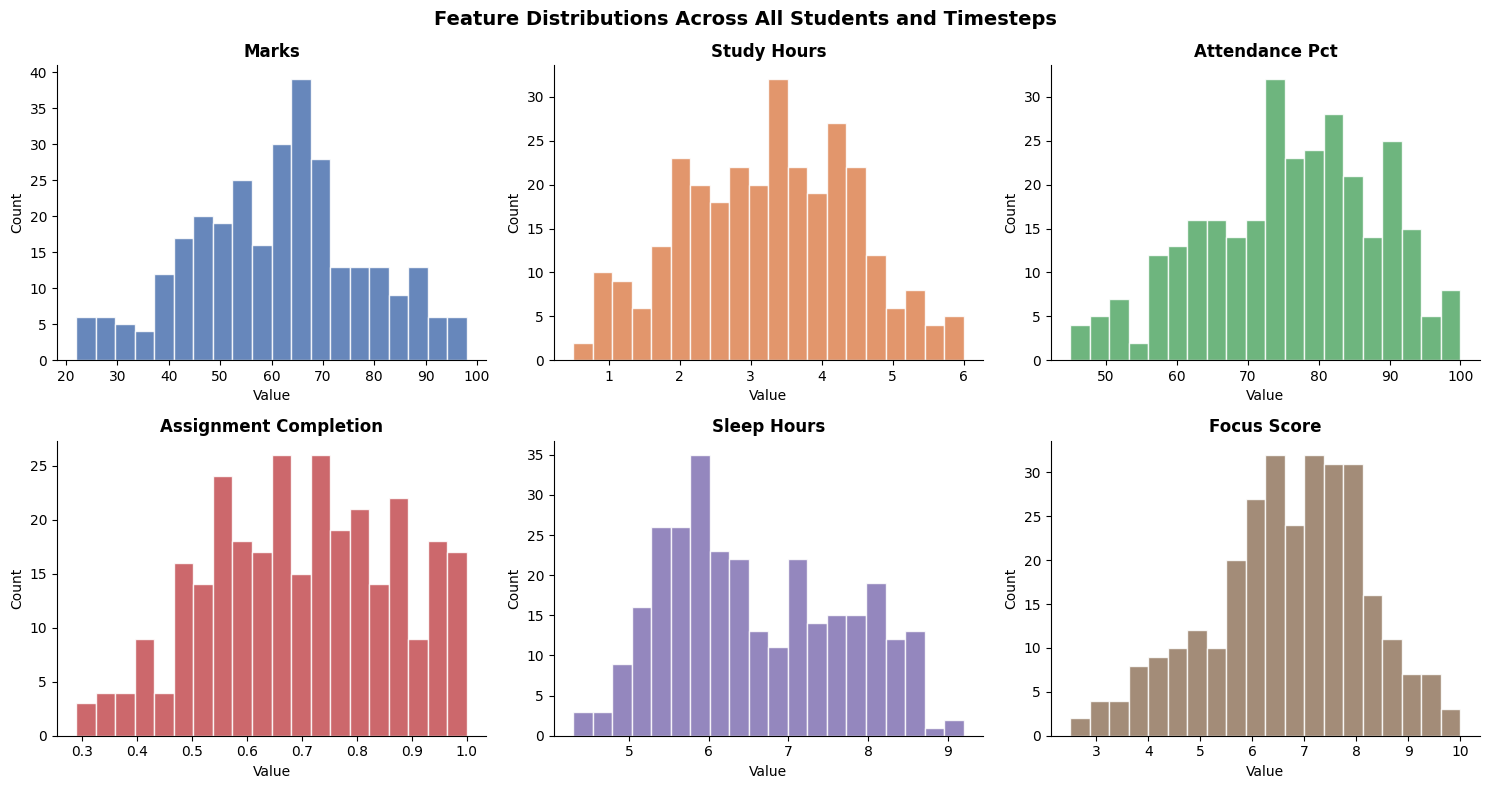

✅ EDA plot saved


In [ ]:
print("📊 Dataset Statistics")
print(df.describe().round(2))
print("\nStudent type distribution:")
print(df[df['timestep'] == 1]['student_type'].value_counts())

FEATURE_COLS = ['marks', 'study_hours', 'attendance_pct',
                'assignment_completion', 'sleep_hours', 'focus_score']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distributions Across All Students and Timesteps',
             fontsize=14, fontweight='bold')

colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3','#937860']
for col, ax, color in zip(FEATURE_COLS, axes.flatten(), colors):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plot saved")

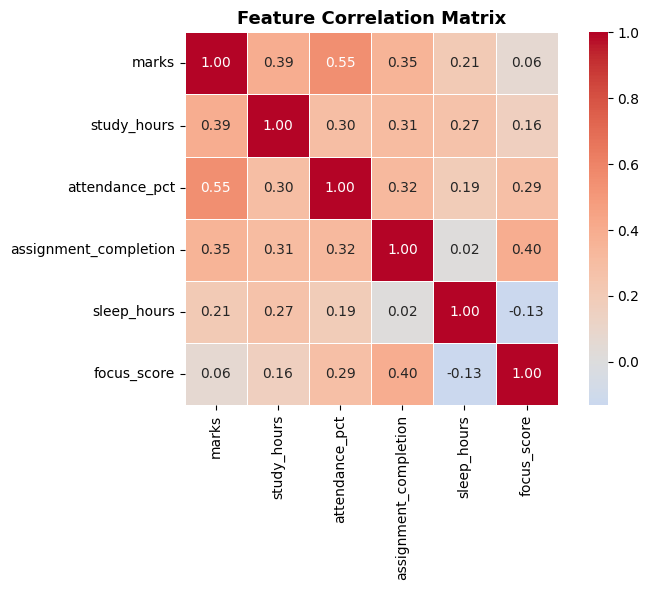

✅ Correlation heatmap saved


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[FEATURE_COLS].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, square=True)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Correlation heatmap saved")

In [ ]:
def compute_growth_index(group):
    group = group.sort_values('timestep').copy()
    marks = group['marks'].values
    gi    = [0.0]
    for i in range(1, len(marks)):
        if marks[i - 1] != 0:
            gi.append(round((marks[i] - marks[i-1]) / marks[i-1] * 100, 2))
        else:
            gi.append(0.0)
    group['growth_index'] = gi
    return group

df = df.groupby('student_id', group_keys=False).apply(compute_growth_index)

def risk_label(gi):
    return 1 if gi < -5 else 0

df['risk'] = df['growth_index'].apply(risk_label)

print("✅ Growth Index computed")
print(df[['student_id','timestep','marks','growth_index','risk']].head(12))

✅ Growth Index computed
   student_id  timestep  marks  growth_index  risk
0      STU001         1     48          0.00     0
1      STU001         2     45         -6.25     1
2      STU001         3     41         -8.89     1
3      STU001         4     40         -2.44     0
4      STU001         5     24        -40.00     1
5      STU001         6     24          0.00     0
6      STU002         1     60          0.00     0
7      STU002         2     55         -8.33     1
8      STU002         3     53         -3.64     0
9      STU002         4     42        -20.75     1
10     STU002         5     38         -9.52     1
11     STU002         6     42         10.53     0


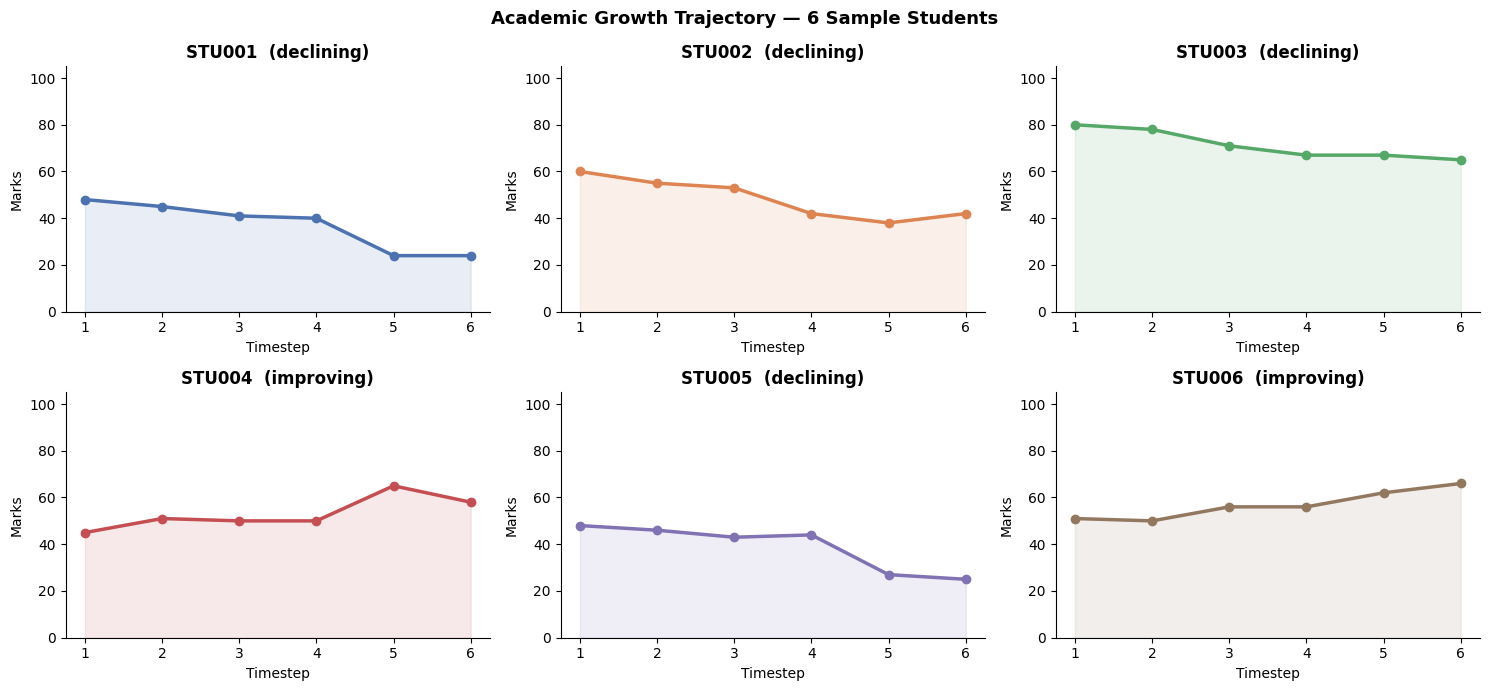

✅ Growth trajectory plots saved


In [ ]:
raw_df          = df.copy()
sample_students = raw_df['student_id'].unique()[:6]
colors_gi       = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3','#937860']

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Academic Growth Trajectory — 6 Sample Students',
             fontweight='bold', fontsize=13)

for ax, sid, color in zip(axes.flatten(), sample_students, colors_gi):
    stu = raw_df[raw_df['student_id'] == sid].sort_values('timestep')
    ax.plot(stu['timestep'], stu['marks'],
            marker='o', color=color, linewidth=2.5)
    ax.fill_between(stu['timestep'], stu['marks'],
                    alpha=0.12, color=color)
    ax.set_title(f"{sid}  ({stu['student_type'].iloc[0]})",
                 fontweight='bold')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Marks')
    ax.set_ylim(0, 105)
    ax.set_xticks(range(1, 7))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('growth_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Growth trajectory plots saved")

In [ ]:
WINDOW     = 5
N_FEATURES = 6
TARGET_COL = 'marks'

scaler = MinMaxScaler()
df[FEATURE_COLS] = scaler.fit_transform(df[FEATURE_COLS])

X_seqs, y_scores, y_risks = [], [], []

for sid in df['student_id'].unique():
    student  = df[df['student_id'] == sid].sort_values('timestep')
    features = student[FEATURE_COLS].values
    risks    = student['risk'].values

    for i in range(len(features) - 1):
        start = max(0, i - WINDOW + 1)
        seq   = features[start : i + 1]
        if len(seq) < WINDOW:
            pad = np.zeros((WINDOW - len(seq), N_FEATURES))
            seq = np.vstack([pad, seq])
        X_seqs.append(seq)
        y_scores.append(features[i + 1][0])
        y_risks.append(risks[i + 1])

X       = np.array(X_seqs)
y_score = np.array(y_scores)
y_risk  = np.array(y_risks)

print(f"✅ Sequences built")
print(f"   X shape      : {X.shape}")
print(f"   y_score shape: {y_score.shape}")
print(f"   y_risk shape : {y_risk.shape}")
print(f"   Risk=1 ratio : {y_risk.mean():.2%}")

✅ Sequences built
   X shape      : (250, 5, 6)
   y_score shape: (250,)
   y_risk shape : (250,)
   Risk=1 ratio : 33.60%


In [ ]:
X_tr, X_te, ys_tr, ys_te, yr_tr, yr_te = train_test_split(
    X, y_score, y_risk, test_size=0.2, random_state=42
)
print(f"✅ Split — Train: {X_tr.shape[0]}  |  Test: {X_te.shape[0]}")

✅ Split — Train: 200  |  Test: 50


In [ ]:
def swish(x):
    """Swish: x · σ(x) — smoother than tanh, better gradient flow."""
    return x * K.sigmoid(x)

class SwishActivation(Layer):
    def call(self, inputs):
        return swish(inputs)
    def get_config(self):
        return super().get_config()

print("✅ Swish activation defined")

✅ Swish activation defined


In [ ]:
class SelfAttention(Layer):
    def __init__(self, units=32, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.W = Dense(units, use_bias=False)
        self.V = Dense(1,     use_bias=False)

    def call(self, hidden_states):
        score   = self.V(tf.nn.tanh(self.W(hidden_states)))
        weights = Softmax(axis=1)(score)
        context = tf.reduce_sum(weights * hidden_states, axis=1)
        return context, weights

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config

print("✅ Self-Attention layer defined")

✅ Self-Attention layer defined


In [ ]:
def build_model(window=WINDOW, n_features=N_FEATURES):
    inp = Input(shape=(window, n_features), name='input_sequence')

    x = LSTM(64, return_sequences=True, name='lstm_1')(inp)
    x = SwishActivation(name='swish_1')(x)
    x = Dropout(0.2, name='dropout_1')(x)

    x = LSTM(32, return_sequences=True, name='lstm_2')(x)
    x = SwishActivation(name='swish_2')(x)

    attention_layer       = SelfAttention(units=32, name='self_attention')
    context, attn_weights = attention_layer(x)

    shared    = Dense(16, activation='relu', name='dense_shared')(context)
    score_out = Dense(1, activation='sigmoid', name='score_output')(shared)
    risk_out  = Dense(1, activation='sigmoid', name='risk_output')(shared)

    model = Model(inputs=inp, outputs=[score_out, risk_out])
    return model

model = build_model()
model.summary()

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss={
        'score_output': 'mse',
        'risk_output' : 'binary_crossentropy'
    },
    loss_weights={
        'score_output': 1.0,
        'risk_output' : 0.5
    },
    metrics={
        'score_output': ['mae'],
        'risk_output' : ['accuracy']
    }
)
print("✅ Model compiled")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 5, 6)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 5, 64)     │     18,176 │ input_sequence[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ swish_1             │ (None, 5, 64)     │          0 │ lstm_1[0][0]      │
│ (SwishActivation)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 5, 64)     │          0 │ swish_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 5, 32)     │     12,416 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ swish_2             │ (None, 5, 32)     │          0 │ lstm_2[0][0]      │
│ (SwishActivation)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ [(None, 32),      │      1,056 │ swish_2[0][0]     │
│ (SelfAttention)     │ (None, 5, 1)]     │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_shared        │ (None, 16)        │        528 │ self_attention[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ score_output        │ (None, 1)         │         17 │ dense_shared[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ risk_output (Dense) │ (None, 1)         │         17 │ dense_shared[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,210 (125.82 KB)

 Trainable params: 32,210 (125.82 KB)

 Non-trainable params: 0 (0.00 B)

✅ Model compiled


In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-5)
]

history = model.fit(
    X_tr,
    {'score_output': ys_tr, 'risk_output': yr_tr},
    validation_split=0.15,
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete")

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - loss: 0.3954 - risk_output_accuracy: 0.6471 - risk_output_loss: 0.6908 - score_output_loss: 0.0514 - score_output_mae: 0.1776 - val_loss: 0.4048 - val_risk_output_accuracy: 0.7667 - val_risk_output_loss: 0.6829 - val_score_output_loss: 0.0637 - val_score_output_mae: 0.2040 - learning_rate: 0.0010
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3918 - risk_output_accuracy: 0.6588 - risk_output_loss: 0.6830 - score_output_loss: 0.0494 - score_output_mae: 0.1775 - val_loss: 0.3987 - val_risk_output_accuracy: 0.7667 - val_risk_output_loss: 0.6704 - val_score_output_loss: 0.0637 - val_score_output_mae: 0.2040 - learning_rate: 0.0010
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3876 - risk_output_accuracy: 0.6588 - risk_output_loss: 0.6752 - score_output_loss: 0.0500 - score_output_mae: 0.1778 - val_loss: 0.3889 - val_risk_output_accuracy: 0.7667 - val_risk_output_loss: 0.6499 - val_score_output_loss: 0.0638

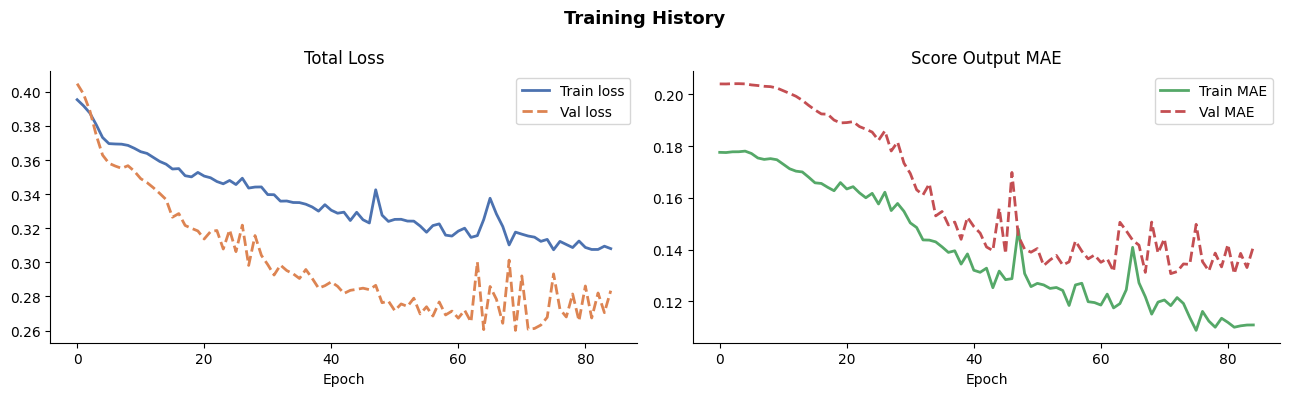

✅ Training curves saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Training History', fontsize=13, fontweight='bold')

axes[0].plot(history.history['loss'],
             label='Train loss', color='#4C72B0', linewidth=2)
axes[0].plot(history.history['val_loss'],
             label='Val loss',   color='#DD8452', linewidth=2, linestyle='--')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(history.history['score_output_mae'],
             label='Train MAE', color='#55A868', linewidth=2)
axes[1].plot(history.history['val_score_output_mae'],
             label='Val MAE',   color='#C44E52', linewidth=2, linestyle='--')
axes[1].set_title('Score Output MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved")

In [ ]:
pred_score, pred_risk = model.predict(X_te, verbose=0)
pred_score       = pred_score.flatten()
pred_risk        = pred_risk.flatten()
pred_risk_binary = (pred_risk > 0.5).astype(int)

mae  = mean_absolute_error(ys_te, pred_score)
rmse = np.sqrt(mean_squared_error(ys_te, pred_score))

actual_trend = np.diff(ys_te)
pred_trend   = np.diff(pred_score)
trend_acc    = np.mean(np.sign(actual_trend) == np.sign(pred_trend))
risk_f1      = f1_score(yr_te, pred_risk_binary, zero_division=0)

print("=" * 45)
print("        EVALUATION RESULTS")
print("=" * 45)
print(f"  Score MAE               : {mae:.4f}")
print(f"  Score RMSE              : {rmse:.4f}")
print(f"  Trend Direction Accuracy: {trend_acc:.2%}")
print(f"  Risk Detection F1 Score : {risk_f1:.4f}")
print("=" * 45)
print(classification_report(yr_te, pred_risk_binary,
      target_names=['Safe (0)', 'At Risk (1)'], zero_division=0))

        EVALUATION RESULTS
  Score MAE               : 0.1442
  Score RMSE              : 0.1764
  Trend Direction Accuracy: 81.63%
  Risk Detection F1 Score : 0.2727
              precision    recall  f1-score   support

    Safe (0)       0.66      1.00      0.79        31
 At Risk (1)       1.00      0.16      0.27        19

    accuracy                           0.68        50
   macro avg       0.83      0.58      0.53        50
weighted avg       0.79      0.68      0.60        50



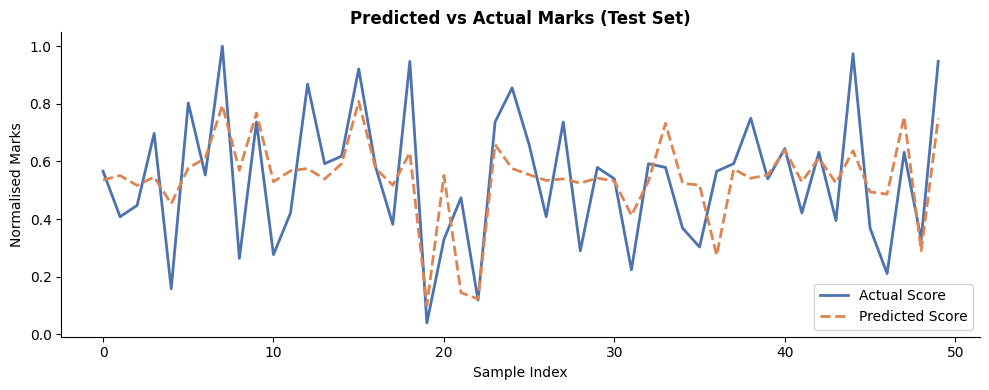

✅ Predicted vs Actual saved


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ys_te,      label='Actual Score',
        color='#4C72B0', linewidth=2)
ax.plot(pred_score, label='Predicted Score',
        color='#DD8452', linewidth=2, linestyle='--')
ax.set_title('Predicted vs Actual Marks (Test Set)', fontweight='bold')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Normalised Marks')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Predicted vs Actual saved")

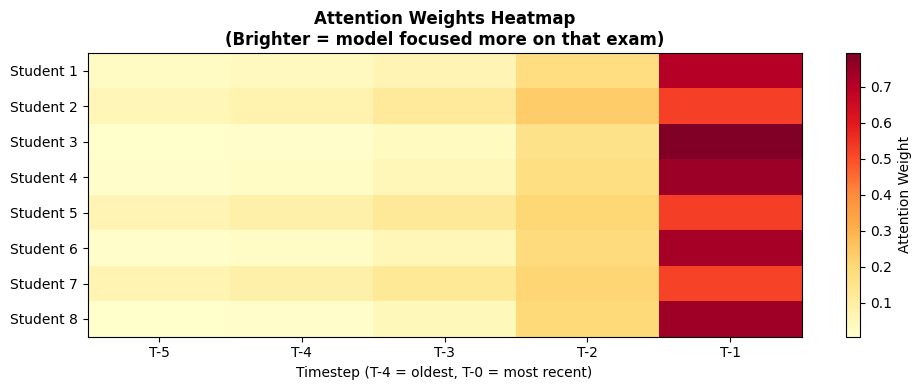

✅ Attention heatmap saved


In [ ]:
attn_model = Model(inputs=model.input,
                   outputs=model.get_layer('self_attention').output)

n_samples      = min(8, len(X_te))
sample_indices = np.random.choice(len(X_te), size=n_samples, replace=False)
X_sample       = X_te[sample_indices]
_, attn_w      = attn_model.predict(X_sample, verbose=0)
attn_w         = attn_w[:, :, 0]

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(attn_w, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(WINDOW))
ax.set_xticklabels([f'T-{WINDOW - i}' for i in range(WINDOW)])
ax.set_yticks(range(n_samples))
ax.set_yticklabels([f'Student {i+1}' for i in range(n_samples)])
ax.set_xlabel('Timestep (T-4 = oldest, T-0 = most recent)')
ax.set_title('Attention Weights Heatmap\n'
             '(Brighter = model focused more on that exam)',
             fontweight='bold')
plt.colorbar(im, ax=ax, label='Attention Weight')
plt.tight_layout()
plt.savefig('attention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Attention heatmap saved")

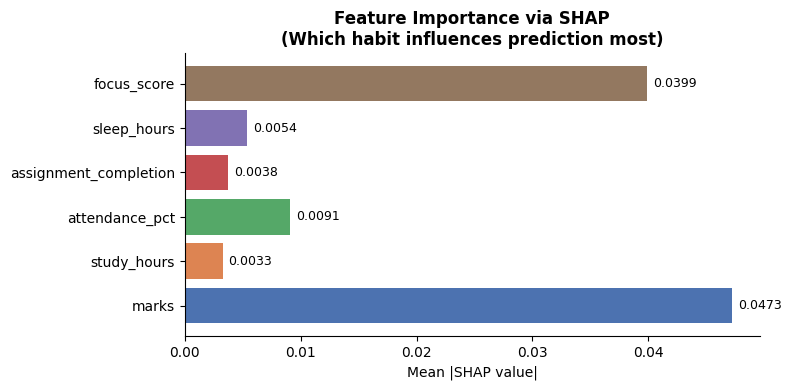

✅ SHAP chart saved


In [ ]:
score_submodel = Model(inputs=model.input,
                       outputs=model.get_layer('score_output').output)

background  = X_tr[:20]
explainer   = shap.GradientExplainer(score_submodel, background)
shap_values = explainer.shap_values(X_te[:20])

if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_2d            = shap_values.reshape(shap_values.shape[0], WINDOW, N_FEATURES)
feature_importance = np.abs(shap_2d).mean(axis=(0, 1))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(FEATURE_COLS, feature_importance,
               color=['#4C72B0','#DD8452','#55A868',
                      '#C44E52','#8172B3','#937860'])
for bar, val in zip(bars, feature_importance):
    ax.text(val + 0.0005,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature Importance via SHAP\n'
             '(Which habit influences prediction most)',
             fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP chart saved")

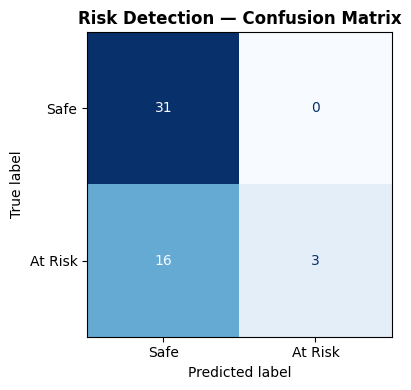

✅ Confusion matrix saved


In [ ]:
cm  = confusion_matrix(yr_te, pred_risk_binary)
cmd = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Safe', 'At Risk'])

fig, ax = plt.subplots(figsize=(5, 4))
cmd.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Risk Detection — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved")


        FULL MODEL COMPARISON
  Random Forest                         : 0.0735
  Gradient Boosting                     : 0.0775
  GRU                                   : 0.0811
  Linear Regression                     : 0.0899
  LSTM + Attention + Swish (Ours)       : 0.1442 ⭐
  BiLSTM                                : 0.1845
  Plain LSTM                            : 0.1889


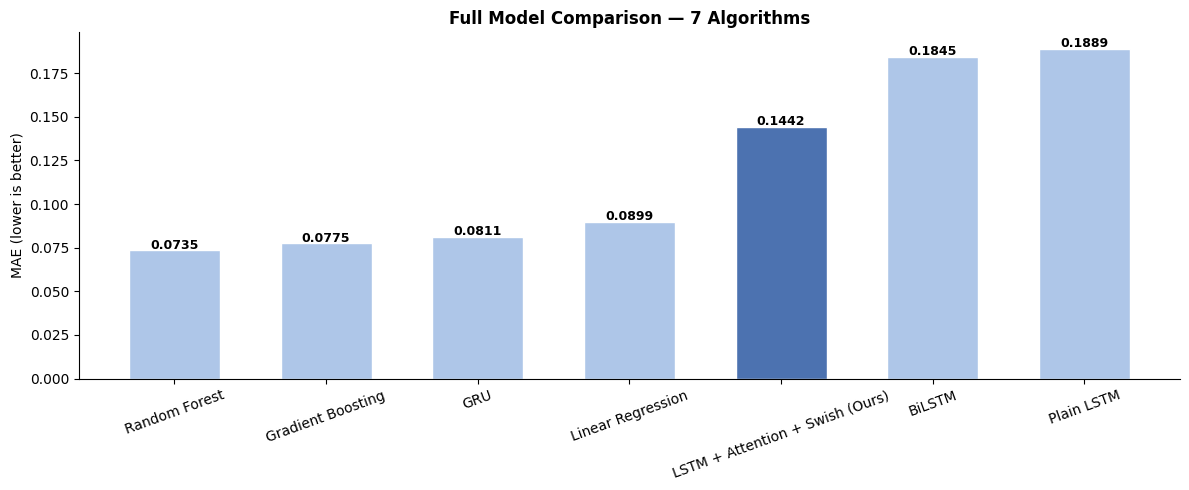

✅ Full model comparison saved


In [ ]:
cb    = [EarlyStopping(patience=10, restore_best_weights=True)]
results = {}

X_flat    = X_tr.reshape(X_tr.shape[0], -1)
X_te_flat = X_te.reshape(X_te.shape[0], -1)

# Linear Regression
lr     = LinearRegression().fit(X_flat, ys_tr)
results['Linear Regression'] = mean_absolute_error(
    ys_te, lr.predict(X_te_flat))

# Random Forest
rf     = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_flat, ys_tr)
results['Random Forest'] = mean_absolute_error(
    ys_te, rf.predict(X_te_flat))

# Gradient Boosting
gb     = GradientBoostingRegressor(n_estimators=100, random_state=42).fit(X_flat, ys_tr)
results['Gradient Boosting'] = mean_absolute_error(
    ys_te, gb.predict(X_te_flat))

# GRU
def build_gru():
    inp = Input(shape=(WINDOW, N_FEATURES))
    x   = GRU(64)(inp)
    out = Dense(1, activation='sigmoid', name='score_output')(x)
    m   = Model(inp, out)
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

m_gru = build_gru()
m_gru.fit(X_tr, ys_tr, epochs=50, batch_size=16,
          validation_split=0.15, verbose=0, callbacks=cb)
results['GRU'] = mean_absolute_error(
    ys_te, m_gru.predict(X_te, verbose=0).flatten())

# Plain LSTM
def build_plain_lstm():
    inp = Input(shape=(WINDOW, N_FEATURES))
    x   = LSTM(64)(inp)
    out = Dense(1, activation='sigmoid', name='score_output')(x)
    m   = Model(inp, out)
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

m_plain = build_plain_lstm()
m_plain.fit(X_tr, ys_tr, epochs=50, batch_size=16,
            validation_split=0.15, verbose=0, callbacks=cb)
results['Plain LSTM'] = mean_absolute_error(
    ys_te, m_plain.predict(X_te, verbose=0).flatten())

# BiLSTM
def build_bilstm():
    inp = Input(shape=(WINDOW, N_FEATURES))
    x   = Bidirectional(LSTM(32))(inp)
    out = Dense(1, activation='sigmoid', name='score_output')(x)
    m   = Model(inp, out)
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

m_bi = build_bilstm()
m_bi.fit(X_tr, ys_tr, epochs=50, batch_size=16,
         validation_split=0.15, verbose=0, callbacks=cb)
results['BiLSTM'] = mean_absolute_error(
    ys_te, m_bi.predict(X_te, verbose=0).flatten())

# Our model
results['LSTM + Attention + Swish (Ours)'] = mae

# Print table
print("\n" + "="*50)
print("        FULL MODEL COMPARISON")
print("="*50)
sorted_results = sorted(results.items(), key=lambda x: x[1])
for name, score in sorted_results:
    star = " ⭐" if "Ours" in name else ""
    print(f"  {name:<38}: {score:.4f}{star}")
print("="*50)

# Chart
fig, ax = plt.subplots(figsize=(12, 5))
names      = [k for k, v in sorted_results]
values     = [v for k, v in sorted_results]
bar_colors = ['#4C72B0' if 'Ours' in n else '#aec6e8' for n in names]
bars = ax.bar(names, values, color=bar_colors,
              edgecolor='white', width=0.6)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f'{val:.4f}', ha='center',
            fontweight='bold', fontsize=9)
ax.set_ylabel('MAE (lower is better)')
ax.set_title('Full Model Comparison — 7 Algorithms', fontweight='bold')
ax.tick_params(axis='x', rotation=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('full_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Full model comparison saved")


🔬 ABLATION STUDY
------------------------------------------
  No Swish (ReLU instead)            : 0.1060
  Full Model (Ours)                  : 0.1442 ⭐
  No Dropout                         : 0.1941
  No Attention (AvgPool)             : 0.1958
------------------------------------------


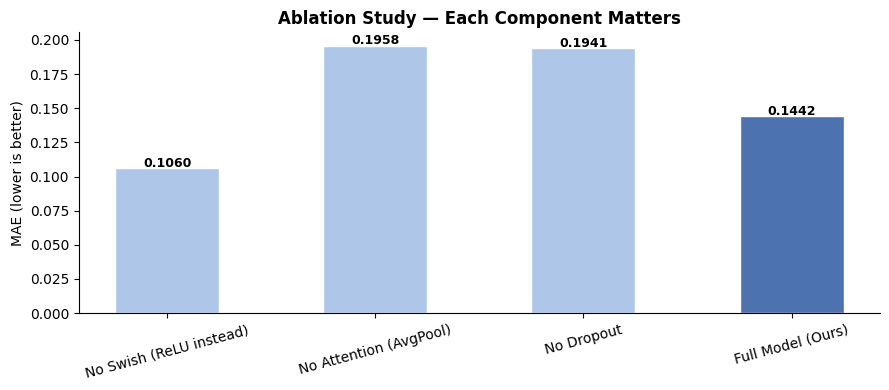

✅ Ablation study saved


In [ ]:
ablation = {}
cb2      = [EarlyStopping(patience=10, restore_best_weights=True)]

# No Swish — use ReLU instead
def build_no_swish():
    inp = Input(shape=(WINDOW, N_FEATURES))
    x   = LSTM(64, return_sequences=True)(inp)
    x   = tf.keras.layers.ReLU()(x)
    x   = Dropout(0.2)(x)
    x   = LSTM(32, return_sequences=True)(x)
    attn    = SelfAttention(units=32)
    ctx, _  = attn(x)
    shared  = Dense(16, activation='relu')(ctx)
    out     = Dense(1, activation='sigmoid', name='score_output')(shared)
    m = Model(inp, out)
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

# No Attention — global average pooling instead
def build_no_attention():
    inp = Input(shape=(WINDOW, N_FEATURES))
    x   = LSTM(64, return_sequences=True)(inp)
    x   = SwishActivation()(x)
    x   = Dropout(0.2)(x)
    x   = LSTM(32, return_sequences=True)(x)
    x   = GlobalAveragePooling1D()(x)
    shared = Dense(16, activation='relu')(x)
    out    = Dense(1, activation='sigmoid', name='score_output')(shared)
    m = Model(inp, out)
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

# No Dropout
def build_no_dropout():
    inp = Input(shape=(WINDOW, N_FEATURES))
    x   = LSTM(64, return_sequences=True)(inp)
    x   = SwishActivation()(x)
    x   = LSTM(32, return_sequences=True)(x)
    attn    = SelfAttention(units=32)
    ctx, _  = attn(x)
    shared  = Dense(16, activation='relu')(ctx)
    out     = Dense(1, activation='sigmoid', name='score_output')(shared)
    m = Model(inp, out)
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

for name, build_fn in [
    ('No Swish (ReLU instead)', build_no_swish),
    ('No Attention (AvgPool)',  build_no_attention),
    ('No Dropout',              build_no_dropout)
]:
    m = build_fn()
    m.fit(X_tr, ys_tr, epochs=50, batch_size=16,
          validation_split=0.15, verbose=0, callbacks=cb2)
    p = m.predict(X_te, verbose=0)
    if isinstance(p, list): p = p[0]
    ablation[name] = mean_absolute_error(ys_te, p.flatten())

ablation['Full Model (Ours)'] = mae

print("\n🔬 ABLATION STUDY")
print("-" * 42)
for k, v in sorted(ablation.items(), key=lambda x: x[1]):
    star = " ⭐" if "Ours" in k else ""
    print(f"  {k:<35}: {v:.4f}{star}")
print("-" * 42)

fig, ax = plt.subplots(figsize=(9, 4))
abl_names  = list(ablation.keys())
abl_values = list(ablation.values())
abl_colors = ['#4C72B0' if 'Ours' in n else '#aec6e8' for n in abl_names]
bars = ax.bar(abl_names, abl_values,
              color=abl_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, abl_values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=9)
ax.set_ylabel('MAE (lower is better)')
ax.set_title('Ablation Study — Each Component Matters', fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Ablation study saved")

In [ ]:
def compute_gi_value(marks_series):
    if len(marks_series) < 2: return 0.0
    prev, curr = marks_series[-2], marks_series[-1]
    return round((curr - prev) / prev * 100, 2) if prev != 0 else 0.0

def get_recommendations(study_hrs, attendance, assignment,
                         sleep, focus, gi):
    recs = []
    if gi > 10:   recs.append(f"✅ GI: +{gi:.1f}% — Excellent! Keep it up.")
    elif gi > 0:  recs.append(f"📈 GI: +{gi:.1f}% — Improving. Stay consistent.")
    elif gi > -5: recs.append(f"⚠️  GI: {gi:.1f}% — Slight dip. Review habits.")
    else:         recs.append(f"🚨 GI: {gi:.1f}% — High risk! Act now.")

    if study_hrs  < 3.0: recs.append(f"📚 Study {study_hrs} hrs — low. Target 3-4 hrs/day.")
    if attendance < 75:  recs.append(f"🏫 Attendance {attendance}% — aim for 85%+.")
    if assignment < 0.7: recs.append(f"📝 Assignments {assignment*100:.0f}% — complete all tasks.")
    if sleep      < 6.0: recs.append(f"😴 Sleep {sleep} hrs — target 7-8 hrs/night.")
    if focus      < 5.0: recs.append(f"🎯 Focus {focus}/10 — try Pomodoro technique.")
    if len(recs)  == 1:  recs.append("🌟 All habits on track. Maintain this!")
    return recs

demo_students = [
    {"id": "STU_A", "marks": [50,58,65,71,78],
     "study": 4.2, "attend": 88, "assign": 0.92,
     "sleep": 7.5, "focus": 8.0},
    {"id": "STU_B", "marks": [80,75,68,61,55],
     "study": 2.1, "attend": 62, "assign": 0.55,
     "sleep": 5.2, "focus": 4.5},
    {"id": "STU_C", "marks": [65,67,63,66,65],
     "study": 3.5, "attend": 79, "assign": 0.80,
     "sleep": 7.0, "focus": 6.5},
]

print("="*55)
print("       RECOMMENDATION ENGINE — DEMO")
print("="*55)
for s in demo_students:
    gi   = compute_gi_value(s['marks'])
    recs = get_recommendations(s['study'], s['attend'],
                                s['assign'], s['sleep'],
                                s['focus'], gi)
    print(f"\nStudent : {s['id']}")
    print(f"Marks   : {s['marks']}")
    print(f"GI      : {gi:+.1f}%")
    for r in recs:
        print(f"  {r}")
print("="*55)

       RECOMMENDATION ENGINE — DEMO

Student : STU_A
Marks   : [50, 58, 65, 71, 78]
GI      : +9.9%
  📈 GI: +9.9% — Improving. Stay consistent.
  🌟 All habits on track. Maintain this!

Student : STU_B
Marks   : [80, 75, 68, 61, 55]
GI      : -9.8%
  🚨 GI: -9.8% — High risk! Act now.
  📚 Study 2.1 hrs — low. Target 3-4 hrs/day.
  🏫 Attendance 62% — aim for 85%+.
  📝 Assignments 55% — complete all tasks.
  😴 Sleep 5.2 hrs — target 7-8 hrs/night.
  🎯 Focus 4.5/10 — try Pomodoro technique.

Student : STU_C
Marks   : [65, 67, 63, 66, 65]
GI      : -1.5%
  ⚠️  GI: -1.5% — Slight dip. Review habits.
  🌟 All habits on track. Maintain this!


In [ ]:
model.save('academic_growth_model.h5')
print("✅ Model saved")

from google.colab import files
import os

output_files = [
    'academic_growth_model.h5',
    'eda_distributions.png',
    'correlation_heatmap.png',
    'growth_trajectories.png',
    'training_curves.png',
    'predicted_vs_actual.png',
    'attention_heatmap.png',
    'shap_feature_importance.png',
    'confusion_matrix.png',
    'full_model_comparison.png',
    'ablation_study.png',
]

print("\n🎉 Downloading all outputs...")
for f in output_files:
    if os.path.exists(f):
        files.download(f)
        print(f"  ⬇️  {f}")
    else:
        print(f"  ⚠️  {f} not found — check if that cell ran")

✅ Model saved

🎉 Downloading all outputs...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  academic_growth_model.h5


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇️  full_model_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  ablation_study.png


In [ ]:
app_code = '''
import streamlit as st
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

st.set_page_config(page_title="Academic Growth Predictor",
                   page_icon="📈", layout="wide")

st.title("📈 AI-Based Academic Growth Prediction System")
st.markdown("##### Hybrid LSTM + Self-Attention + Swish Activation")
st.markdown("---")

st.sidebar.header("Enter Student Data")
st.sidebar.subheader("Marks per Exam")
marks = [st.sidebar.slider(f"Exam {i+1}", 0, 100,
         [55, 60, 65, 68, 72][i]) for i in range(5)]

st.sidebar.subheader("Current Habits")
study  = st.sidebar.slider("Study hours / day",    0.0, 10.0, 3.5, 0.1)
attend = st.sidebar.slider("Attendance %",          40,  100,  78)
assign = st.sidebar.slider("Assignment completion", 0.0, 1.0,  0.80, 0.01)
sleep  = st.sidebar.slider("Sleep hours / night",   4.0, 9.5,  7.0,  0.1)
focus  = st.sidebar.slider("Focus score (1-10)",    1.0, 10.0, 6.5,  0.1)

def compute_gi(m):
    if m[-2] == 0: return 0.0
    return round((m[-1] - m[-2]) / m[-2] * 100, 2)

def gi_all(m):
    out = [0.0]
    for i in range(1, len(m)):
        out.append(round((m[i]-m[i-1])/m[i-1]*100,2) if m[i-1]!=0 else 0.0)
    return out

def feature_scores(study, attend, assign, sleep, focus):
    return {
        "Study hours"           : round(min(study/6.0, 1.0), 3),
        "Attendance"            : round(min(attend/95.0, 1.0), 3),
        "Assignment completion" : round(assign, 3),
        "Sleep quality"         : round(min((sleep-4.0)/5.5, 1.0), 3),
        "Focus score"           : round(focus/10.0, 3),
    }

def feature_impacts(scores):
    weights = {"Study hours":0.28,"Attendance":0.24,
               "Assignment completion":0.20,
               "Sleep quality":0.16,"Focus score":0.12}
    return {f: round((s-1.0)*weights[f]*100, 2)
            for f, s in scores.items()}

def explain_feature(feat, score, impact, study, attend, assign, sleep, focus):
    lines = {
        "Study hours":{
            "high" :f"You study {study:.1f} hrs/day. Strong habit pushing GI up by {abs(impact):.1f} points.",
            "medium":f"You study {study:.1f} hrs/day. Slightly below 6 hr ideal, costing {abs(impact):.1f} GI points.",
            "low"  :f"Only {study:.1f} hrs/day study. Biggest drag on GI, pulling it down by {abs(impact):.1f} points. Target 3-4 hrs.",
        },
        "Attendance":{
            "high" :f"Attendance {attend}%. Excellent. Contributing +{abs(impact):.1f} to GI.",
            "medium":f"Attendance {attend}%. Slightly below ideal. Costing {abs(impact):.1f} GI points.",
            "low"  :f"Attendance only {attend}%. Missing classes hurting GI by {abs(impact):.1f} points.",
        },
        "Assignment completion":{
            "high" :f"{assign*100:.0f}% assignments done. Great. Contributing +{abs(impact):.1f} to GI.",
            "medium":f"{assign*100:.0f}% assignments done. Losing {abs(impact):.1f} GI points here.",
            "low"  :f"Only {assign*100:.0f}% assignments done. Pulling GI down by {abs(impact):.1f} points.",
        },
        "Sleep quality":{
            "high" :f"{sleep:.1f} hrs sleep. Healthy. Adding +{abs(impact):.1f} to GI.",
            "medium":f"{sleep:.1f} hrs sleep slightly low. Costing {abs(impact):.1f} GI points.",
            "low"  :f"Only {sleep:.1f} hrs sleep. Brain cannot consolidate learning. Hurting GI by {abs(impact):.1f} points.",
        },
        "Focus score":{
            "high" :f"Focus {focus:.1f}/10. Highly focused. Contributing +{abs(impact):.1f} to GI.",
            "medium":f"Focus {focus:.1f}/10 moderate. Costing {abs(impact):.1f} GI points.",
            "low"  :f"Focus only {focus:.1f}/10. Low focus wastes study time. Dragging GI down by {abs(impact):.1f} points.",
        },
    }
    tier = "high" if score>=0.80 else "medium" if score>=0.55 else "low"
    return lines[feat][tier]

gi      = compute_gi(marks)
gi_vals = gi_all(marks)
trend   = "Improving" if gi>0 else "Declining" if gi<0 else "Stable"
risk    = gi < -5
scores  = feature_scores(study, attend, assign, sleep, focus)
impacts = feature_impacts(scores)

c1,c2,c3,c4,c5 = st.columns(5)
c1.metric("Growth Index",  f"{gi:+.1f}%", delta=trend)
c2.metric("Risk Status",   "At Risk" if risk else "Safe",
          delta="High risk" if risk else "Stable", delta_color="inverse")
c3.metric("Latest Marks",  f"{marks[-1]}")
c4.metric("Avg Marks",     f"{round(float(np.mean(marks)),1)}")
c5.metric("Trend",         trend)
st.markdown("---")

left, right = st.columns(2)
with left:
    st.subheader("Marks trajectory")
    fig1, ax1 = plt.subplots(figsize=(6,3))
    ax1.plot(range(1,6), marks, marker="o", color="#4C72B0", linewidth=2.5)
    ax1.fill_between(range(1,6), marks, alpha=0.12, color="#4C72B0")
    ax1.set_xlabel("Exam"); ax1.set_ylabel("Marks")
    ax1.set_ylim(0,105); ax1.set_xticks(range(1,6))
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    plt.tight_layout(); st.pyplot(fig1); plt.close()

with right:
    st.subheader("Growth Index per exam")
    gi_colors = ["#55A868" if g>=0 else "#C44E52" for g in gi_vals]
    fig2, ax2 = plt.subplots(figsize=(6,3))
    ax2.bar(range(1,6), gi_vals, color=gi_colors, edgecolor="white", width=0.6)
    ax2.axhline(0,  color="black", linewidth=0.8, linestyle="--")
    ax2.axhline(-5, color="red",   linewidth=0.8, linestyle=":",
                label="Risk threshold (-5%)")
    ax2.set_xlabel("Exam"); ax2.set_ylabel("GI (%)")
    ax2.legend(fontsize=9)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    plt.tight_layout(); st.pyplot(fig2); plt.close()

st.markdown("---")
st.subheader(f"Why is your Growth Index {gi:+.1f}%?")
st.markdown("Green bars push your GI up. Red bars pull it down.")

feat_names = list(impacts.keys())
feat_vals  = list(impacts.values())
bar_colors = ["#55A868" if v>=0 else "#C44E52" for v in feat_vals]

fig3, ax3 = plt.subplots(figsize=(8, 3.5))
bars = ax3.barh(feat_names, feat_vals, color=bar_colors,
                edgecolor="white", height=0.55)
ax3.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, feat_vals):
    xpos = val+0.15 if val>=0 else val-0.15
    ha   = "left" if val>=0 else "right"
    ax3.text(xpos, bar.get_y()+bar.get_height()/2,
             f"{val:+.1f}", va="center", ha=ha,
             fontsize=10, fontweight="bold",
             color="#27500A" if val>=0 else "#791F1F")
ax3.set_xlabel("Contribution to Growth Index (GI points)")
ax3.set_title("Feature impact on your Growth Index", fontweight="bold")
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
plt.tight_layout(); st.pyplot(fig3); plt.close()

st.markdown("### What each habit is doing to your score")
for feat in feat_names:
    score      = scores[feat]
    impact     = impacts[feat]
    explanation = explain_feature(feat, score, impact,
                                   study, attend, assign, sleep, focus)
    if score >= 0.80:   st.success(f"**{feat}** — {explanation}")
    elif score >= 0.55: st.warning(f"**{feat}** — {explanation}")
    else:               st.error(f"**{feat}** — {explanation}")

st.markdown("---")
st.subheader("What should you fix first?")
sorted_impacts = sorted(impacts.items(), key=lambda x: x[1])
worst = sorted_impacts[0]
best  = sorted_impacts[-1]
st.markdown(f"Biggest drag: **{worst[0]}** pulling GI down by {abs(worst[1]):.1f} points. Fix this first.")
st.markdown(f"Strongest habit: **{best[0]}** boosting GI by +{abs(best[1]):.1f} points. Keep doing this.")

priority_fixes = [f for f,v in sorted_impacts if v < 0]
if priority_fixes:
    st.markdown("**Priority action list (worst first):**")
    for i, feat in enumerate(priority_fixes):
        st.markdown(f"{i+1}. Fix **{feat}** — costing {abs(impacts[feat]):.1f} GI points")
else:
    st.success("All habits contributing positively to your Growth Index!")

st.markdown("---")
st.subheader("What-If Simulator")
st.markdown("Adjust habits below and see how your GI would change.")
sim_study  = st.slider("Simulate study hours",  0.0, 10.0, float(study),  0.1)
sim_attend = st.slider("Simulate attendance %",  40,  100,  int(attend))
sim_sleep  = st.slider("Simulate sleep hours",   4.0, 9.5,  float(sleep),  0.1)
sim_focus  = st.slider("Simulate focus score",   1.0, 10.0, float(focus),  0.1)

sim_scores  = feature_scores(sim_study, sim_attend, assign, sim_sleep, sim_focus)
sim_impacts = feature_impacts(sim_scores)
sim_total   = sum(sim_impacts.values())
cur_total   = sum(impacts.values())
sim_change  = round(sim_total - cur_total, 2)

if sim_change > 0:
    st.success(f"With these changes your GI contribution score improves by +{sim_change:.1f} points")
elif sim_change < 0:
    st.error(f"These changes would reduce your GI contribution by {abs(sim_change):.1f} points")
else:
    st.info("No change in GI with these habit adjustments")

st.markdown("---")
st.subheader("Habit profile radar")
categories    = list(scores.keys())
vals_norm     = list(scores.values())
vals_closed   = vals_norm + [vals_norm[0]]
angles        = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles_closed = angles + [angles[0]]

fig4, ax4 = plt.subplots(figsize=(4.5,4.5), subplot_kw=dict(polar=True))
ax4.plot(angles_closed, vals_closed, color="#4C72B0", linewidth=2)
ax4.fill(angles_closed, vals_closed, color="#4C72B0", alpha=0.2)
ax4.set_xticks(angles)
ax4.set_xticklabels(categories, fontsize=9)
ax4.set_ylim(0,1)
ax4.set_yticks([0.25,0.5,0.75,1.0])
ax4.set_yticklabels(["25%","50%","75%","100%"], fontsize=7)
ax4.set_title("Habit profile", fontweight="bold", pad=15)

col_r, col_s = st.columns([1,2])
with col_r:
    st.pyplot(fig4); plt.close()
with col_s:
    st.markdown("**Score breakdown**")
    for feat, score in scores.items():
        pct    = int(score*100)
        filled = int(pct/10)
        bar_s  = "█"*filled + "░"*(10-filled)
        color  = "green" if score>=0.80 else "orange" if score>=0.55 else "red"
        st.markdown(f"`{feat}` &nbsp; :{color}[{bar_s}] &nbsp; **{pct}%**",
                    unsafe_allow_html=True)

st.markdown("---")
st.caption("AI-Based Personal Academic Growth Prediction System | LSTM + Self-Attention + Swish | 2025-2026")
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("✅ app.py written successfully")

✅ app.py written successfully


In [ ]:
import subprocess, time
from google.colab.output import eval_js

subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
time.sleep(3)

proc = subprocess.Popen(
    ["streamlit", "run", "app.py",
     "--server.port", "8501",
     "--server.headless", "true",
     "--server.enableCORS", "false",
     "--server.enableXsrfProtection", "false"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)
time.sleep(8)

url = eval_js("google.colab.kernel.proxyPort(8501)")
print("=" * 55)
print("🌐 Open this link in your browser:")
print(url)
print("=" * 55)

🌐 Open this link in your browser:
https://8501-m-s-kkb-usw1b2-ethorzirdv8n-b.us-west1-2.prod.colab.dev
